<a href="https://colab.research.google.com/github/NidhiDekate/car-price-multimodal-dl/blob/main/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - exploratory data analysis

this notebook explores the matched dataset (40,658 rows) to understand
the data before building any models.

key questions we answer:
- what does the price distribution look like?
- which features correlate most with price?
- are there outliers we need to remove?
- what patterns exist in the data?

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# paths
BASE = '/content/drive/MyDrive/CarPricePrediction/'
MATCHED_CSV = BASE + 'data/tabular/df_matched.csv'

# load matched dataset
df = pd.read_csv(MATCHED_CSV)
print("shape:", df.shape)
print("columns:", df.columns.tolist())

Mounted at /content/drive
shape: (40658, 17)
columns: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate', 'stanford_class']


Origional tabular dataset: 558K rows → ML models (LightGBM, CatBoost, XGBoost)
             trained on full tabular data, no images needed

MATCHED dataset : 40K rows  → Multimodal model (CNN + ANN)
             trained on matched subset with images

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40658 entries, 0 to 40657
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            40658 non-null  int64  
 1   make            40658 non-null  object 
 2   model           40658 non-null  object 
 3   trim            40630 non-null  object 
 4   body            40592 non-null  object 
 5   transmission    35458 non-null  object 
 6   vin             40658 non-null  object 
 7   state           40658 non-null  object 
 8   condition       40281 non-null  float64
 9   odometer        40656 non-null  float64
 10  color           40574 non-null  object 
 11  interior        40574 non-null  object 
 12  seller          40658 non-null  object 
 13  mmr             40658 non-null  float64
 14  sellingprice    40658 non-null  float64
 15  saledate        40658 non-null  object 
 16  stanford_class  40658 non-null  object 
dtypes: float64(4), int64(1), object

In [ ]:
df.isnull().sum()

,0
year,0
make,0
model,0
trim,28
body,66
transmission,5200
vin,0
state,0
condition,377
odometer,2


In [ ]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,stanford_class
0,2012,Acura,Tsx,Base,Sedan,automatic,jh4cu2f43cc007761,ca,39.0,43127.0,black,black,ahfc/honda lease trust/hvt inc. eot,16450.0,17800.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),Acura TSX Sedan 2012
1,2012,Bmw,3 Series,335is,Convertible,automatic,wbadx1c56ce570700,ca,38.0,14149.0,black,black,financial services remarketing (lease),39900.0,40500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),BMW 3 Series Sedan 2012
2,2012,Bmw,3 Series,328i,Convertible,automatic,wbadw7c5xce729000,ca,31.0,27675.0,blue,gray,financial services remarketing (lease),28200.0,25750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),BMW 3 Series Sedan 2012
3,2012,Bmw,1 Series,135i,Coupe,automatic,wbauc9c56cvm12464,ca,41.0,16288.0,blue,—,financial services remarketing (lease),26900.0,27500.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),BMW 1 Series Convertible 2012
4,2012,Acura,Tl,Base,Sedan,automatic,19uua8f23ca002640,ca,41.0,28395.0,gray,black,ahfc/honda lease trust/hvt inc. eot,19200.0,20200.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),Acura TL Sedan 2012


selling price stats:
count     40658.000000
mean      15999.416499
std        8550.648539
min         100.000000
25%       10900.000000
50%       14400.000000
75%       20800.000000
max      169500.000000
Name: sellingprice, dtype: float64


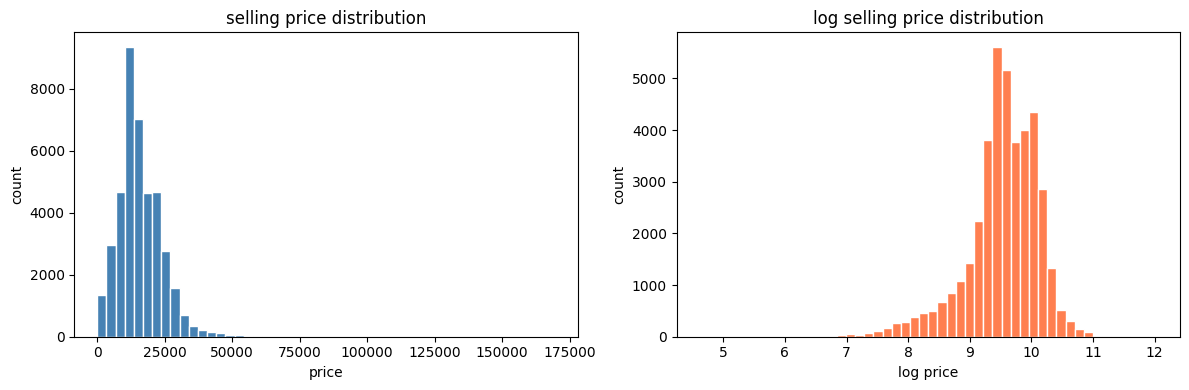

In [ ]:
# understand our target variable - selling price
print("selling price stats:")
print(df['sellingprice'].describe())

plt.figure(figsize=(12, 4))

# raw distribution
plt.subplot(1, 2, 1)
plt.hist(df['sellingprice'], bins=50, color='steelblue', edgecolor='white')
plt.title('selling price distribution')
plt.xlabel('price')
plt.ylabel('count')

# log distribution
plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['sellingprice']), bins=50, color='coral', edgecolor='white')
plt.title('log selling price distribution')
plt.xlabel('log price')
plt.ylabel('count')

plt.tight_layout()
plt.show()

In [ ]:
# check suspiciously low and high prices
print("cars under $1000:")
print(df[df['sellingprice'] < 1000][['make', 'model', 'year', 'sellingprice']].head(10))

print("\ncars over $100,000:")
print(df[df['sellingprice'] > 100000][['make', 'model', 'year', 'sellingprice']].head(10))

cars under $1000:
           make       model  year  sellingprice
669   Chevrolet      Cobalt  2010         500.0
924   Chevrolet      Impala  2007         400.0
1058       Ford       Focus  2007         300.0
3977   Chrysler  Pt Cruiser  2008         900.0
4007  Chevrolet      Impala  2007         900.0
4566   Chrysler  Pt Cruiser  2008         900.0
4568   Chrysler  Pt Cruiser  2008         350.0
4859  Chevrolet      Cobalt  2010         275.0
4863  Chevrolet      Cobalt  2010         400.0
4871   Chrysler  Pt Cruiser  2008         850.0

cars over $100,000:
              make           model  year  sellingprice
127        Ferrari      California  2012      154000.0
432        Bentley  Continental Gt  2012      118000.0
1415       Ferrari      California  2012      156000.0
9039   Rolls-Royce           Ghost  2012      169500.0
9280       Bentley  Continental Gt  2012      125000.0
10035         Audi              R8  2012      120000.0
15199         Audi              R8  2012      10

In [ ]:
# remove suspiciously low prices
print("rows before:", len(df))
df = df[df['sellingprice'] >= 1000].copy()
print("rows after:", len(df))
print("removed:", 40658 - len(df))

rows before: 40658
rows after: 40602
removed: 56


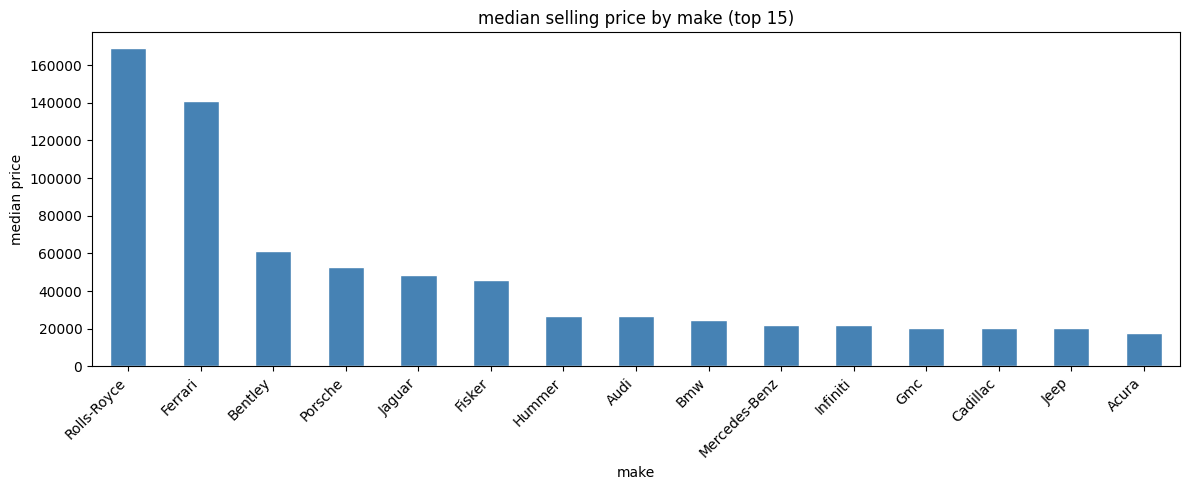

In [ ]:
# average price by car make
avg_price_by_make = df.groupby('make')['sellingprice'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
avg_price_by_make.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('median selling price by make (top 15)')
plt.xlabel('make')
plt.ylabel('median price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

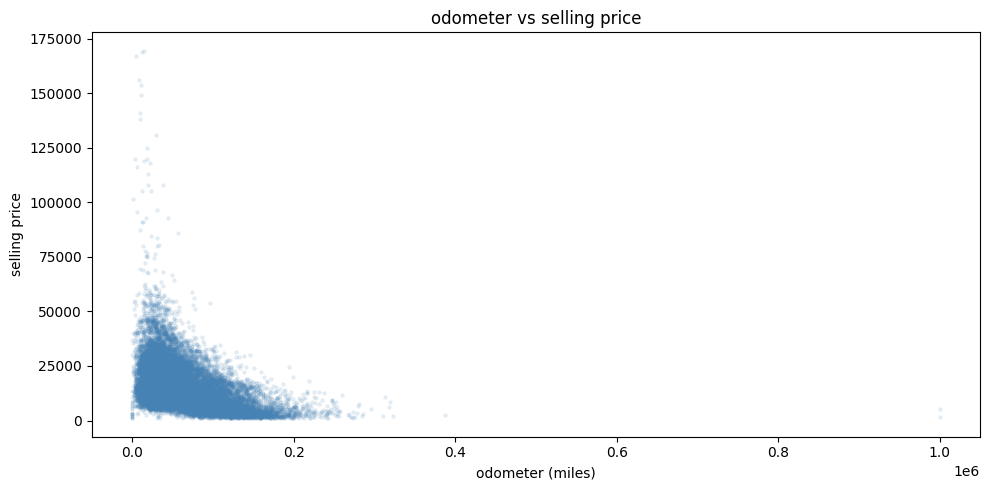

odometer stats:
count     40600.000000
mean      51303.016970
std       35605.875064
min           1.000000
25%       28840.750000
50%       39608.000000
75%       62383.500000
max      999999.000000
Name: odometer, dtype: float64


In [10]:
# odometer vs price relationship
plt.figure(figsize=(10, 5))
plt.scatter(df['odometer'], df['sellingprice'], alpha=0.1, color='steelblue', s=5)
plt.title('odometer vs selling price')
plt.xlabel('odometer (miles)')
plt.ylabel('selling price')
plt.tight_layout()
plt.show()

print("odometer stats:")
print(df['odometer'].describe())

In [12]:
# check percentiles to decide cutoff scientifically
print("odometer percentiles:")
print(df['odometer'].quantile([0.90, 0.95, 0.99, 0.999]))

odometer percentiles:
0.900    100772.700
0.950    124504.000
0.990    172315.890
0.999    241429.223
Name: odometer, dtype: float64


In [13]:
# remove odometer outliers - keeping 99%+ of real data
print("rows before:", len(df))
df = df[df['odometer'] < 200000].copy()
print("rows after:", len(df))
print("removed:", 40602 - len(df))

rows before: 40592
rows after: 40437
removed: 165


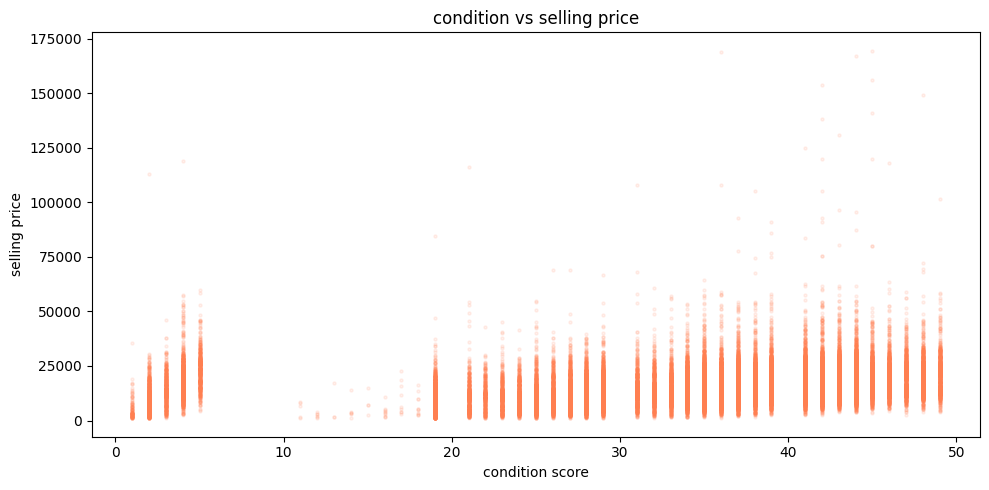

condition stats:
count    40068.000000
mean        33.537936
std         11.611041
min          1.000000
25%         28.000000
50%         36.000000
75%         42.000000
max         49.000000
Name: condition, dtype: float64


In [14]:
# condition vs price
plt.figure(figsize=(10, 5))
plt.scatter(df['condition'], df['sellingprice'], alpha=0.1, color='coral', s=5)
plt.title('condition vs selling price')
plt.xlabel('condition score')
plt.ylabel('selling price')
plt.tight_layout()
plt.show()

print("condition stats:")
print(df['condition'].describe())

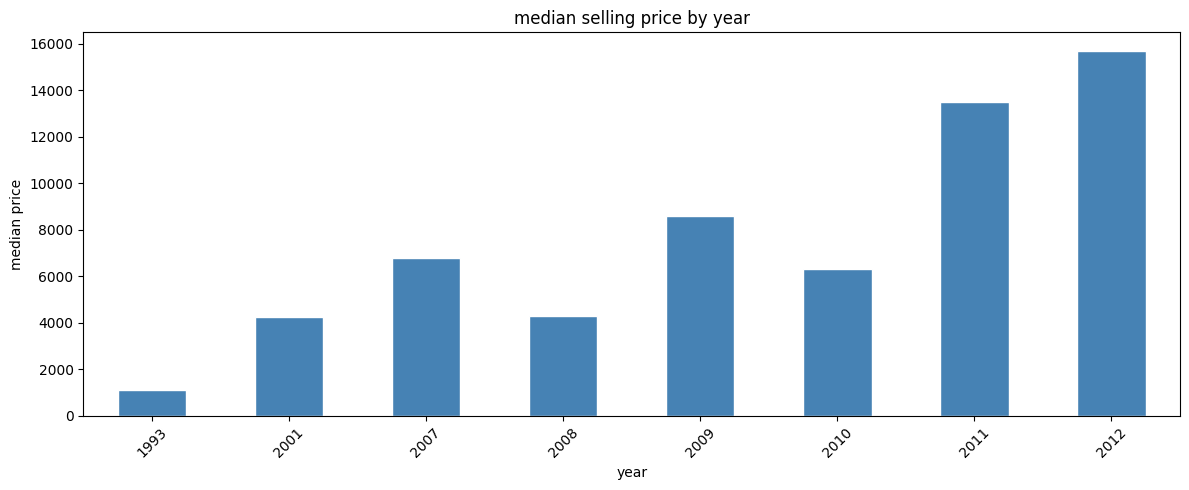

In [15]:
# average price by year
avg_price_by_year = df.groupby('year')['sellingprice'].median().sort_index()

plt.figure(figsize=(12, 5))
avg_price_by_year.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('median selling price by year')
plt.xlabel('year')
plt.ylabel('median price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

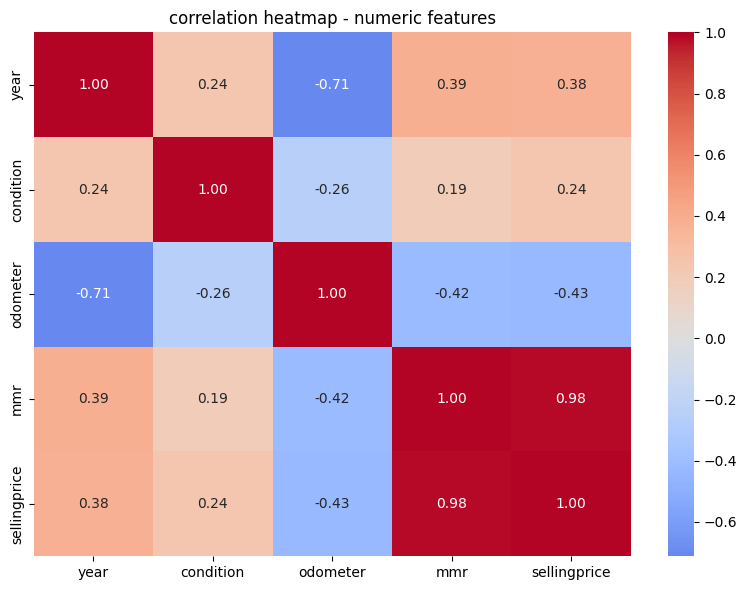

In [16]:
# correlation between numeric features and price
numeric_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('correlation heatmap - numeric features')
plt.tight_layout()
plt.show()

In [19]:
import zipfile

zip_path = BASE + 'data/images/archive.zip'
LOCAL_IMG = '/content/stanford_cars/'
os.makedirs(LOCAL_IMG, exist_ok=True)

print("re-extracting images...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_IMG)

re-extracting images...


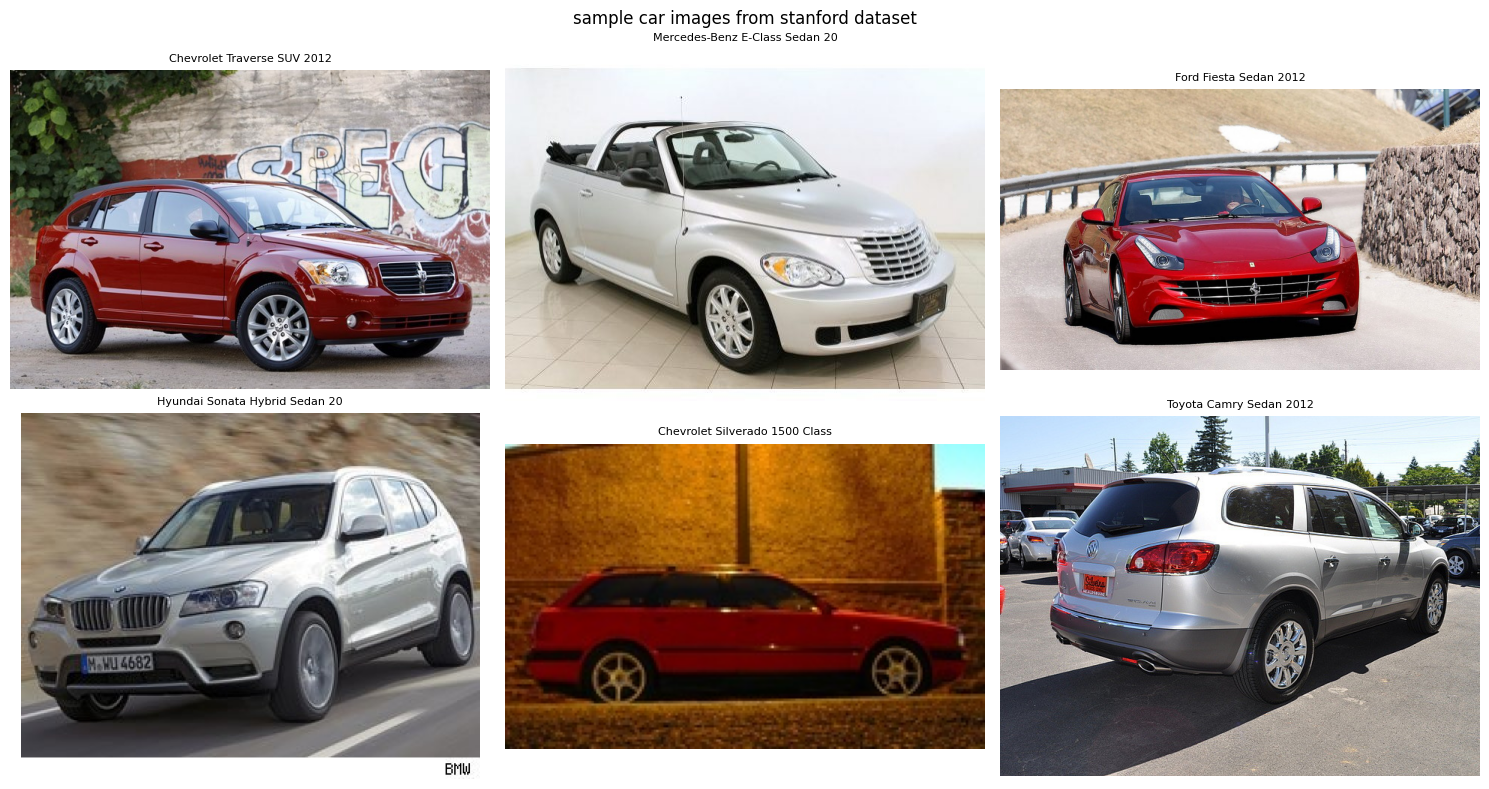

In [20]:
import matplotlib.image as mpimg

train_path = '/content/stanford_cars/cars_train/cars_train/'

# show 6 sample images with their stanford class
sample = df.sample(6, random_state=42)[['stanford_class']].values

plt.figure(figsize=(15, 8))
for i, (class_name,) in enumerate(sample):
    img_file = os.listdir(train_path)[i * 100]
    img = mpimg.imread(os.path.join(train_path, img_file))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name[:30], fontsize=8)
    plt.axis('off')

plt.suptitle('sample car images from stanford dataset')
plt.tight_layout()
plt.show()

1. price is right skewed → use log transform for target
2. mmr = 0.98 correlation with price → drop it (leakage)
3. make is strongest predictor → luxury brands dominate
2. odometer strong negative predictor (-0.43)
4. year strong positive predictor (0.38)  
5. condition weaker than expected (0.24)
6. 2008/2010 price dips reflect financial crisis
7. images are good quality with some variation

In [21]:
# save cleaned dataframe
save_path = BASE + 'data/tabular/df_cleaned.csv'
df.to_csv(save_path, index=False)
print("saved cleaned dataframe")
print("final shape:", df.shape)

saved cleaned dataframe
final shape: (40437, 17)
